In [1]:
import os
import pandas as pd
from pathlib import Path
import numpy as np
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB, DataSetPontine
import Functional_Fusion.dataset as ds
from ProbabilisticParcellation.util import plot_multi_flat
import nibabel as nb
import subprocess
import paths as paths
import Functional_Fusion.connectivity as conn
import matplotlib.pyplot as plt
from scripts.var_decomp import reshape_data
import SUITPy as suit
import nitools as nt
import PcmPy as pcm
import seaborn as sb


/Users/callithrix/code/Python/IndividualParcellation/env/lib/python3.9/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)


In [2]:
base_dir = paths.set_base_dir()
atlas_dir = paths.set_atlas_dir(base_dir)
atlas_dir = base_dir + '/Atlases'
figure_dir = paths.set_figure_dir()

## Network exploration

In [3]:
# Load the cortical networks
net = nb.load(base_dir +
                f'/targets/Net69_space-fs32k.dscalar.nii')


In [4]:
# Get correlation matrix of net_data
net_data = net.get_fdata()

In [5]:
# Correlate each network with the others
correlation = np.corrcoef(net_data)

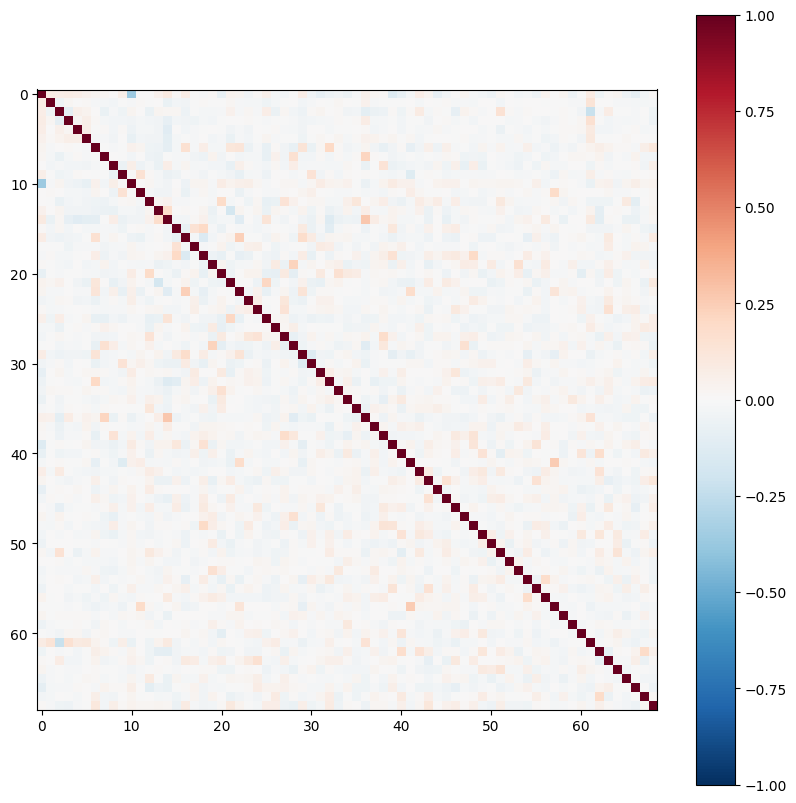

In [7]:

# Plot the correlation matrix with red-white-blue colormap
plt.figure(figsize=(10, 10))
plt.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar()
